In [362]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [363]:
df = pd.read_csv('D:\\project\\AA\\4. California House\\Housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [364]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [365]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [366]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [367]:
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [368]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [369]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

In [370]:
df['bedroom_ratio_percenteage'] = df['total_bedrooms'] / df['total_rooms'] * 100
df['bedroom_ratio_percenteage']

0        14.659091
1        15.579659
2        12.951602
3        18.445840
4        17.209588
           ...    
20635    22.462462
20636    21.520803
20637    21.517303
20638    21.989247
20639    22.118492
Name: bedroom_ratio_percenteage, Length: 20640, dtype: float64

In [371]:
df['population_per_household'] = df['population'] / df['households']

In [372]:
df['rooms_per_person'] = df['total_bedrooms'] / df['population']

In [373]:
df['housing_median_age'].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52.])

In [374]:
bins = [0, 10, 20, 30, 40, np.inf]
labels=['new', 'young', 'middle', 'old', 'very_old']

df['age_house_category'] = pd.cut(df['housing_median_age'], bins=bins, labels=labels)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedroom_ratio_percenteage,population_per_household,rooms_per_person,age_house_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,14.659091,2.555556,0.400621,very_old
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,15.579659,2.109842,0.460641,middle
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,12.951602,2.802260,0.383065,very_old
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,18.445840,2.547945,0.421147,very_old
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,17.209588,2.181467,0.495575,very_old
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,22.462462,2.560606,0.442604,middle
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,21.520803,3.122807,0.421348,young
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,21.517303,2.325635,0.481629,young
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,21.989247,2.123209,0.551957,young


In [375]:
df.groupby('ocean_proximity')['median_house_value'].mean()

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

In [376]:
df['near_ocean'] = df['ocean_proximity'].isin(['<1H OCEAN', 'NEAR BAY', 'NEAR OCEAN']).astype('category')
df['near_ocean'] = df['near_ocean'].cat.codes
df['near_ocean']

0        1
1        1
2        1
3        1
4        1
        ..
20635    0
20636    0
20637    0
20638    0
20639    0
Name: near_ocean, Length: 20640, dtype: int8

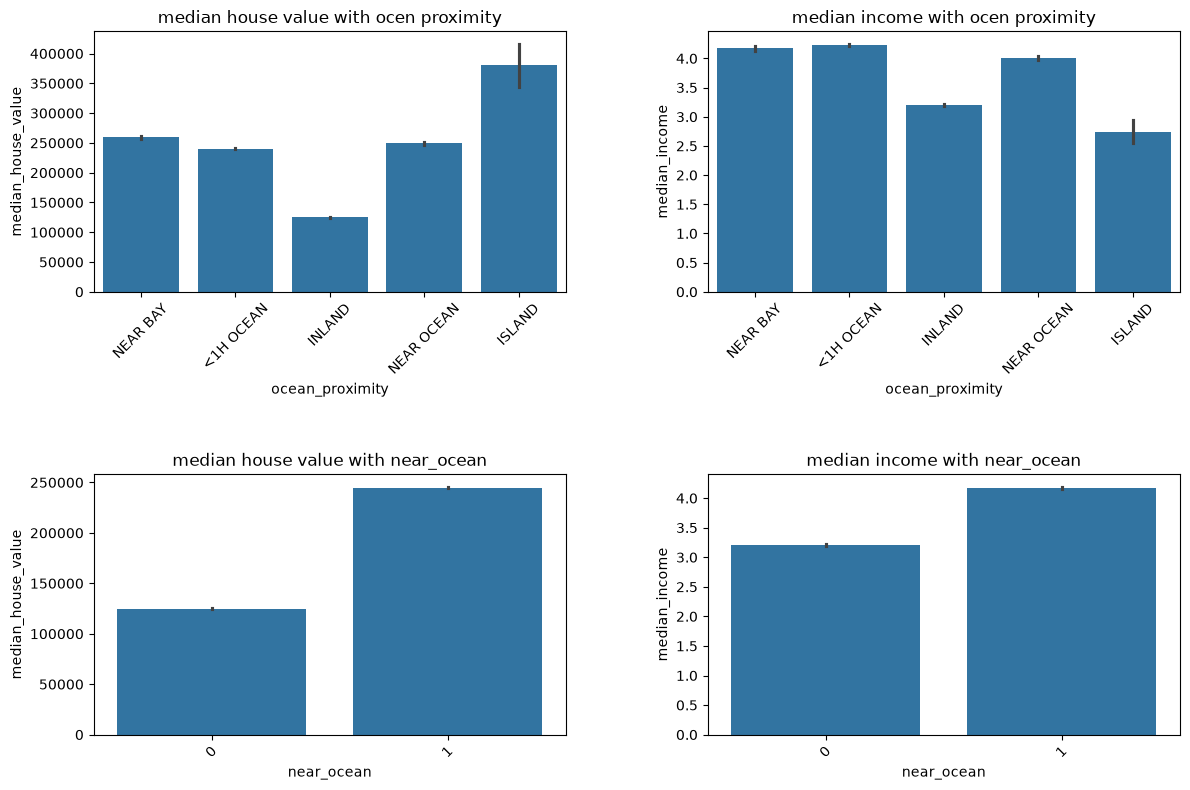

In [377]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value',
    errorbar='se',
    ax=axs[0, 0]
)
axs[0, 0].tick_params(axis='x', rotation=45)
axs[0, 0].set_title('median house value with ocen proximity')


sns.barplot(
    data=df,
    x='ocean_proximity',
    y='median_income',
    errorbar='se',
    ax=axs[0, 1]
)
axs[0, 1].tick_params(axis='x', rotation=45)
axs[0, 1].set_title('median income with ocen proximity')

sns.barplot(
    data=df,
    x='near_ocean',
    y='median_house_value',
    errorbar='se',
    ax=axs[1, 0]
)
axs[1, 0].tick_params(axis='x', rotation=45)
axs[1, 0].set_title('median house value with near_ocean')


sns.barplot(
    data=df,
    x='near_ocean',
    y='median_income',
    errorbar='se',
    ax=axs[1, 1]
)
axs[1, 1].tick_params(axis='x', rotation=45)
axs[1, 1].set_title('median income with near_ocean')



plt.tight_layout()
plt.subplots_adjust(hspace=0.7, wspace=0.3)

In [378]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   longitude                  20640 non-null  float64 
 1   latitude                   20640 non-null  float64 
 2   housing_median_age         20640 non-null  float64 
 3   total_rooms                20640 non-null  float64 
 4   total_bedrooms             20433 non-null  float64 
 5   population                 20640 non-null  float64 
 6   households                 20640 non-null  float64 
 7   median_income              20640 non-null  float64 
 8   median_house_value         20640 non-null  float64 
 9   ocean_proximity            20640 non-null  str     
 10  rooms_per_household        20640 non-null  float64 
 11  bedroom_ratio_percenteage  20433 non-null  float64 
 12  population_per_household   20640 non-null  float64 
 13  rooms_per_person           20433 non-null 

<Axes: xlabel='median_house_value', ylabel='Count'>

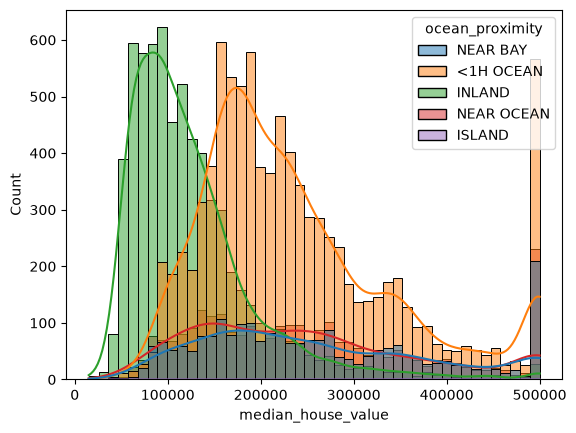

In [379]:
sns.histplot(df, x='median_house_value', kde=True, hue='ocean_proximity')

In [380]:
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedroom_ratio_percenteage,population_per_household,rooms_per_person,age_house_category,near_ocean,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,14.659091,2.555556,0.400621,very_old,1,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,15.579659,2.109842,0.460641,middle,1,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,12.951602,2.802260,0.383065,very_old,1,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,18.445840,2.547945,0.421147,very_old,1,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,17.209588,2.181467,0.495575,very_old,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,5.045455,22.462462,2.560606,0.442604,middle,0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,6.114035,21.520803,3.122807,0.421348,young,0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,5.205543,21.517303,2.325635,0.481629,young,0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,5.329513,21.989247,2.123209,0.551957,young,0,0,1,0,0,0


In [381]:
df['age_house_category_code'] = df['age_house_category'].cat.codes

In [382]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   longitude                   20640 non-null  float64 
 1   latitude                    20640 non-null  float64 
 2   housing_median_age          20640 non-null  float64 
 3   total_rooms                 20640 non-null  float64 
 4   total_bedrooms              20433 non-null  float64 
 5   population                  20640 non-null  float64 
 6   households                  20640 non-null  float64 
 7   median_income               20640 non-null  float64 
 8   median_house_value          20640 non-null  float64 
 9   rooms_per_household         20640 non-null  float64 
 10  bedroom_ratio_percenteage   20433 non-null  float64 
 11  population_per_household    20640 non-null  float64 
 12  rooms_per_person            20433 non-null  float64 
 13  age_house_category         

In [383]:
abs(df.drop(columns='age_house_category').corr()['median_house_value']).sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_INLAND        0.484859
near_ocean                    0.483978
ocean_proximity_<1H OCEAN     0.256617
bedroom_ratio_percenteage     0.255880
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
latitude                      0.144160
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
age_house_category_code       0.091337
rooms_per_person              0.069896
households                    0.065843
total_bedrooms                0.049686
longitude                     0.045967
population                    0.024650
population_per_household      0.023737
ocean_proximity_ISLAND        0.023416
Name: median_house_value, dtype: float64

In [384]:
df['location_zone'] = (
    df['latitude'].round(1).astype(str)
    + '_'
    + df['longitude'].round(1).astype(str)
)
df['location_zone'].value_counts().shape

(1563,)

In [385]:
df['location_zone'].nunique()

1563

In [386]:
print(df['longitude'].mean())
print(df['latitude'].mean())

-119.56970445736432
35.63186143410852


In [387]:
df['longitude'] - df['longitude'].mean()

0       -2.660296
1       -2.650296
2       -2.670296
3       -2.680296
4       -2.680296
           ...   
20635   -1.520296
20636   -1.640296
20637   -1.650296
20638   -1.750296
20639   -1.670296
Name: longitude, Length: 20640, dtype: float64

In [388]:
df['distance_from_center'] = (
    (df['longitude'] - df['longitude'].mean())**2 +
    (df['latitude'] - df['latitude'].mean())**2
)**0.5
df['distance_from_center'].describe()


count    20640.000000
mean         2.745208
std          1.019755
min          0.120879
25%          2.092457
50%          2.604947
75%          3.472759
max          7.804914
Name: distance_from_center, dtype: float64

In [389]:
abs(df.drop(columns=['age_house_category', 'location_zone']).corr()['median_house_value']).sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_INLAND        0.484859
near_ocean                    0.483978
ocean_proximity_<1H OCEAN     0.256617
bedroom_ratio_percenteage     0.255880
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
latitude                      0.144160
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
age_house_category_code       0.091337
rooms_per_person              0.069896
distance_from_center          0.069569
households                    0.065843
total_bedrooms                0.049686
longitude                     0.045967
population                    0.024650
population_per_household      0.023737
ocean_proximity_ISLAND        0.023416
Name: median_house_value, dtype: float64

In [390]:
df.isna().sum()

longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
rooms_per_household             0
bedroom_ratio_percenteage     207
population_per_household        0
rooms_per_person              207
age_house_category              0
near_ocean                      0
ocean_proximity_<1H OCEAN       0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
age_house_category_code         0
location_zone                   0
distance_from_center            0
dtype: int64

<Axes: xlabel='median_house_value', ylabel='Count'>

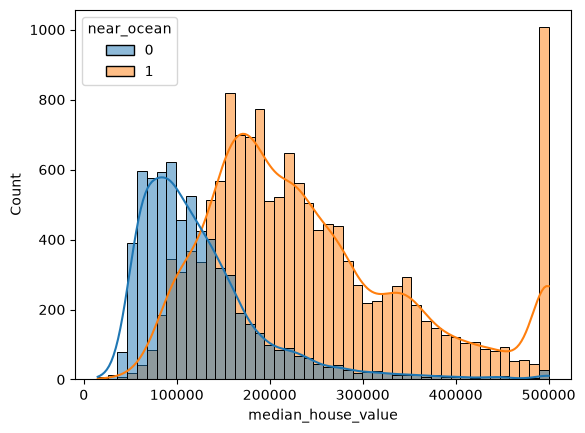

In [398]:
sns.histplot(df, x='median_house_value', kde=True, hue='near_ocean')

In [391]:
df['near_ocean']

0        1
1        1
2        1
3        1
4        1
        ..
20635    0
20636    0
20637    0
20638    0
20639    0
Name: near_ocean, Length: 20640, dtype: int8

In [392]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   longitude                   20640 non-null  float64 
 1   latitude                    20640 non-null  float64 
 2   housing_median_age          20640 non-null  float64 
 3   total_rooms                 20640 non-null  float64 
 4   total_bedrooms              20433 non-null  float64 
 5   population                  20640 non-null  float64 
 6   households                  20640 non-null  float64 
 7   median_income               20640 non-null  float64 
 8   median_house_value          20640 non-null  float64 
 9   rooms_per_household         20640 non-null  float64 
 10  bedroom_ratio_percenteage   20433 non-null  float64 
 11  population_per_household    20640 non-null  float64 
 12  rooms_per_person            20433 non-null  float64 
 13  age_house_category         

In [393]:
abs(df.drop(columns=['age_house_category', 'location_zone']).corr()['median_house_value']).sort_values(ascending=False) > 0.05

median_house_value             True
median_income                  True
ocean_proximity_INLAND         True
near_ocean                     True
ocean_proximity_<1H OCEAN      True
bedroom_ratio_percenteage      True
ocean_proximity_NEAR BAY       True
rooms_per_household            True
latitude                       True
ocean_proximity_NEAR OCEAN     True
total_rooms                    True
housing_median_age             True
age_house_category_code        True
rooms_per_person               True
distance_from_center           True
households                     True
total_bedrooms                False
longitude                     False
population                    False
population_per_household      False
ocean_proximity_ISLAND        False
Name: median_house_value, dtype: bool

In [394]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,...,age_house_category,near_ocean,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,age_house_category_code,location_zone,distance_from_center
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,...,very_old,1,0,0,0,1,0,4,37.9_-122.2,3.483001
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,...,middle,1,0,0,0,1,0,2,37.9_-122.2,3.462466
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,...,very_old,1,0,0,0,1,0,4,37.8_-122.2,3.471400
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,...,very_old,1,0,0,0,1,0,4,37.8_-122.2,3.479098
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,...,very_old,1,0,0,0,1,0,4,37.8_-122.2,3.479098


<Axes: xlabel='median_income', ylabel='median_house_value'>

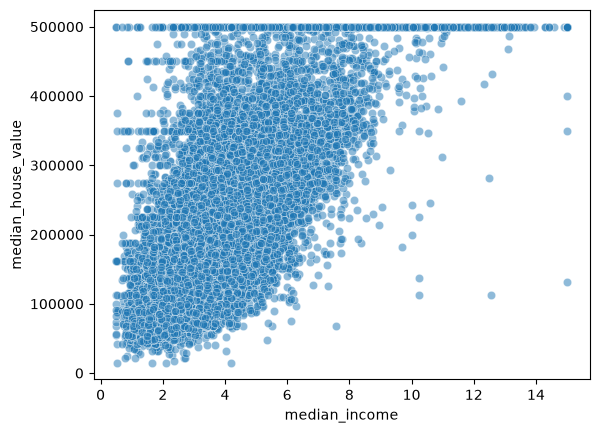

In [395]:
sns.scatterplot(df, x='median_income',y='median_house_value', alpha=0.5)

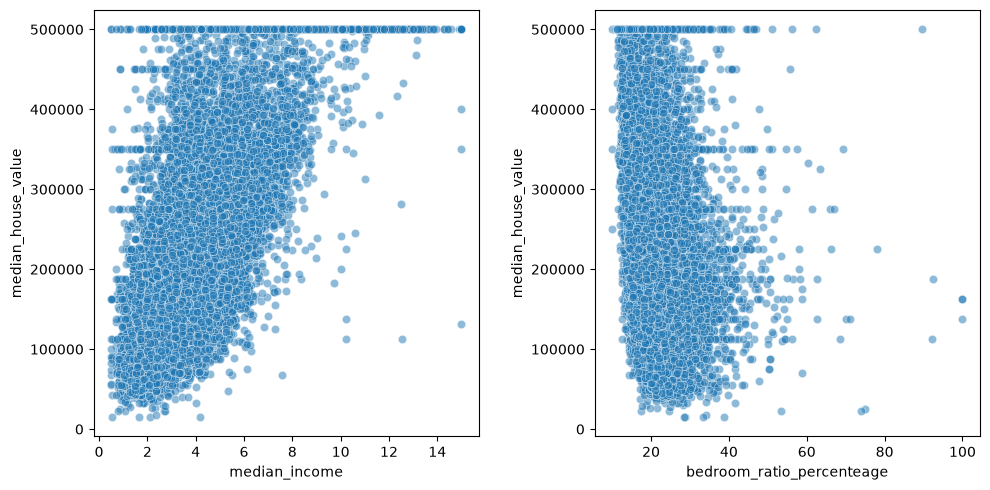

In [396]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(df, x='median_income',y='median_house_value', alpha=0.5, ax=axs[0])

sns.scatterplot(df, x='bedroom_ratio_percenteage',y='median_house_value', alpha=0.5, ax=axs[1])




plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)

In [397]:
X = df.drop(
    columns=['median_house_value', 'total_bedrooms', 'longitude', 'population', 'population_per_household', 'ocean_proximity_ISLAND']
)

y = df['median_house_value']

In [400]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

In [407]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


assert X_train.shape[1] == X_test.shape[1]
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]